# Gradiente Descendente para Regressão Linear

No notebook anterior, encontramos os parâmetros ótimos da regressão linear usando a **fórmula analítica OLS**:

$$\hat{\theta} = (\mathbf{X}^\top \mathbf{X})^{-1} \mathbf{X}^\top \mathbf{y}$$

Isso funciona porque a loss L2 + modelo linear produz uma superfície de erro **convexa** com solução fechada.

Mas a maioria dos modelos de ML (redes neurais, regressão logística, etc.) **não possui** solução analítica. Para esses casos, usamos **otimização iterativa** — e o método mais fundamental é o **gradient descent** (gradiente descendente).

Neste notebook, vamos:
1. Entender a intuição do gradient descent
2. Derivar o gradiente para regressão linear com loss L2
3. Implementar o algoritmo do zero
4. Explorar o efeito da learning rate
5. Visualizar a trajetória no espaço de parâmetros
6. Comparar os resultados com OLS

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

---
## 1. Recapitulação — Risco Empírico e Otimização

Relembrando do notebook anterior:

- **Modelo**: $\hat{y} = \mathbf{X}\theta$
- **Risco empírico** (SSE): $\mathcal{R}_{\text{emp}}(\theta) = \|\mathbf{y} - \mathbf{X}\theta\|_2^2 = \sum_{i=1}^{n}(y^{(i)} - \theta^\top \mathbf{x}^{(i)})^2$
- **Objetivo**: encontrar $\hat{\theta} = \arg\min_\theta \mathcal{R}_{\text{emp}}(\theta)$

### Recriando o dataset

Usamos exatamente o mesmo dataset sintético do notebook 01 (mesma seed, mesmos parâmetros).

In [4]:
np.random.seed(42)
n = 100

area = np.random.uniform(40, 150, n)
rooms = np.random.randint(1, 7, n)
age = np.random.uniform(0, 50, n)

TRUE_INTERCEPT = 50
TRUE_BETA_AREA = 2.5
TRUE_BETA_ROOMS = 15
TRUE_BETA_AGE = -1.5

noise = np.random.normal(0, 20, n)
price = (TRUE_INTERCEPT
         + TRUE_BETA_AREA * area
         + TRUE_BETA_ROOMS * rooms
         + TRUE_BETA_AGE * age
         + noise)

houses = pd.DataFrame({
    'area_m2': area, 'rooms': rooms,
    'age_years': age, 'price_1000': price
})
houses.head()

,area_m2,rooms,age_years,price_1000
0,81.199413,1,25.409939,238.256414
1,144.578574,4,34.790640,404.696889
2,120.519334,5,42.917940,325.883664
3,105.852433,4,16.297945,359.538507
4,57.162050,6,11.012052,235.358369


In [5]:
# Calcular a solução OLS para referência
X_ols = np.column_stack([np.ones(n), area, rooms, age])
y = price

theta_ols = np.linalg.inv(X_ols.T @ X_ols) @ X_ols.T @ y
print("Solução OLS (referência):")
print(f"  Intercept: {theta_ols[0]:.4f}")
print(f"  area_m2:   {theta_ols[1]:.4f}")
print(f"  rooms:     {theta_ols[2]:.4f}")
print(f"  age_years: {theta_ols[3]:.4f}")

Solução OLS (referência):
  Intercept: 42.6796
  area_m2:   2.6459
  rooms:     14.0657
  age_years: -1.5912


---
## 2. Intuição do Gradiente Descendente

Imagine que você está em uma montanha coberta de neblina e quer chegar ao vale mais baixo. Você não consegue ver o vale, mas pode sentir a **inclinação do chão** sob seus pés.

Estratégia: a cada passo, caminhe na direção de **maior descida** (o oposto do gradiente).

### A regra de atualização

$$\theta^{[t+1]} = \theta^{[t]} - \alpha \cdot \frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta}(\theta^{[t]})$$

onde:
- $\theta^{[t]}$ é o valor atual dos parâmetros na iteração $t$
- $\alpha$ é a **learning rate** (taxa de aprendizado) — controla o tamanho do passo
- $\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta}$ é o **gradiente** — aponta na direção de maior crescimento da loss
- O sinal negativo faz com que caminhemos na direção **oposta** (de descida)

---
## 3. Derivação do Gradiente para Regressão Linear com L2

Precisamos calcular o gradiente de $\mathcal{R}_{\text{emp}}(\theta) = \|\mathbf{y} - \mathbf{X}\theta\|_2^2$.

Definindo o vetor de resíduos $\mathbf{e} = \mathbf{y} - \mathbf{X}\theta$:

$$\mathcal{R}_{\text{emp}}(\theta) = \mathbf{e}^\top \mathbf{e} = (\mathbf{y} - \mathbf{X}\theta)^\top(\mathbf{y} - \mathbf{X}\theta)$$

Aplicando a regra da cadeia (como visto nos slides):

$$\frac{\partial \mathcal{R}_{\text{emp}}}{\partial \theta} = -2\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\theta)$$

Portanto, a regra de atualização do gradient descent fica:

$$\theta^{[t+1]} = \theta^{[t]} + 2\alpha \cdot \mathbf{X}^\top(\mathbf{y} - \mathbf{X}\theta^{[t]})$$

Nota: na prática, muitas implementações usam o **Mean Squared Error** (MSE) em vez de SSE, dividindo por $n$. Isso muda a escala do gradiente, mas não o ponto de mínimo. Vamos usar o MSE para que a learning rate não dependa do tamanho do dataset:

$$\text{MSE}(\theta) = \frac{1}{n}\|\mathbf{y} - \mathbf{X}\theta\|_2^2$$

$$\nabla_\theta \text{MSE} = -\frac{2}{n}\mathbf{X}^\top(\mathbf{y} - \mathbf{X}\theta)$$

---
## 4. Implementação do Gradient Descent

### 4.1 Normalização das features

Antes de aplicar gradient descent, é importante **normalizar** as features para que tenham escalas comparáveis. Sem normalização, features com valores grandes (como `area_m2` ~ 40-150) dominam o gradiente em relação a features com valores menores (como `rooms` ~ 1-6), e a convergência fica muito lenta ou instável.

É importante para métodos baseados em distância, produto interno ou gradiente, e não afeta modelos baseados em árvores.

In [12]:
# Normalizar as features (z-score): x_norm = (x - média) / desvio_padrão
X_raw = np.column_stack([area, rooms, age])

X_mean = X_raw.mean(axis=0)
X_std = X_raw.std(axis=0)
X_norm = (X_raw - X_mean) / X_std

# Adicionar coluna de 1s para o intercept
X_gd = np.column_stack([np.ones(n), X_norm])

print("Médias das features:", X_mean)
print("Desvios padrão:", X_std)
print("Shape de X_gd:", X_gd.shape)
print("\nPrimeiras 3 linhas (normalizadas com intercept):")
print(X_gd[:3])

Médias das features: [91.71988177  3.48       27.56156314]
Desvios padrão: [32.55980493  1.78594513 13.82282499]
Shape de X_gd: (100, 4)

Primeiras 3 linhas (normalizadas com intercept):
[[ 1.         -0.32311215 -1.38862049 -0.15565735]
 [ 1.          1.62343393  0.29116236  0.52298117]
 [ 1.          0.88450935  0.85108998  1.11094347]]


### 4.2 O algoritmo

In [13]:
def gradient_descent(X, y, learning_rate, n_iterations, theta_init=None):
    """
    Executa gradient descent para regressão linear com loss MSE.

    Retorna:
        theta_final: parâmetros otimizados
        loss_history: MSE em cada iteração
        theta_history: parâmetros em cada iteração
    """
    n_samples, n_features = X.shape
    if theta_init is not None:
        theta = theta_init.copy()
    else:
        theta = np.zeros(n_features)

    loss_history = []
    theta_history = [theta.copy()]

    for i in range(n_iterations):
        y_pred = X @ theta
        residuals = y - y_pred
        mse = np.mean(residuals ** 2)
        loss_history.append(mse)
        gradient = -(2 / n_samples) * (X.T @ residuals)
        theta = theta - learning_rate * gradient
        theta_history.append(theta.copy())

    return theta, loss_history, np.array(theta_history)

In [29]:
learning_rate = 0.1
n_iterations = 200

theta_gd, loss_history, theta_history = gradient_descent(
    X_gd, y, learning_rate, n_iterations
)

print(f"MSE inicial:  {loss_history[0]:.2f}")
print(f"MSE final:    {loss_history[-1]:.2f}")
print(f"\nParâmetros finais (espaço normalizado):")
print(f"  theta_0 (intercept): {theta_gd[0]:.4f}")
print(f"  theta_1 (area):      {theta_gd[1]:.4f}")
print(f"  theta_2 (rooms):     {theta_gd[2]:.4f}")
print(f"  theta_3 (age):       {theta_gd[3]:.4f}")

MSE inicial:  93405.09
MSE final:    454.63

Parâmetros finais (espaço normalizado):
  theta_0 (intercept): 290.4549
  theta_1 (area):      86.1501
  theta_2 (rooms):     25.1206
  theta_3 (age):       -21.9946


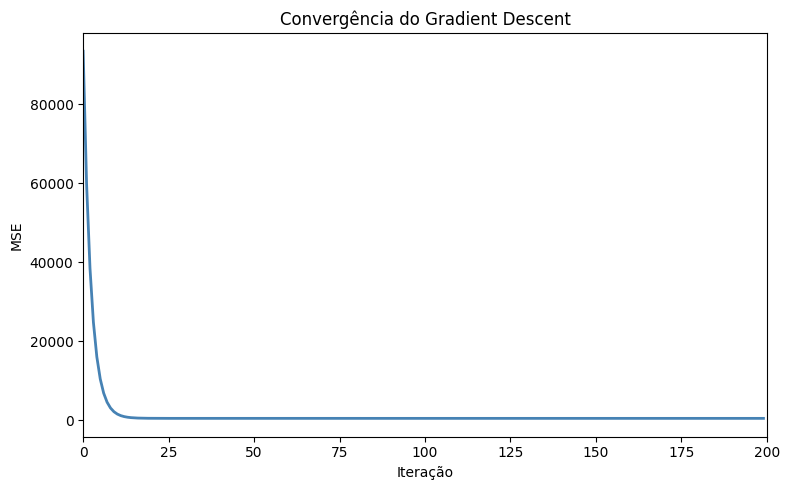

In [30]:
# Gráfico: MSE ao longo das iterações
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(loss_history, color='steelblue', linewidth=2)
ax.set_xlabel('Iteração')
ax.set_ylabel('MSE')
ax.set_title('Convergência do Gradient Descent')
ax.set_xlim(0, n_iterations)
plt.tight_layout()
plt.show()

A loss cai rapidamente nas primeiras iterações e depois estabiliza — o algoritmo **convergiu** para o mínimo.

---
## 5. Efeito da Learning Rate

A learning rate $\alpha$ é o hiperparâmetro mais importante do gradient descent:

- **$\alpha$ adequado**: convergência suave até o mínimo
- **$\alpha$ muito pequeno**: convergência muito lenta (muitas iterações)
- **$\alpha$ muito grande**: os passos são grandes demais, o algoritmo "pula" o mínimo e **diverge**

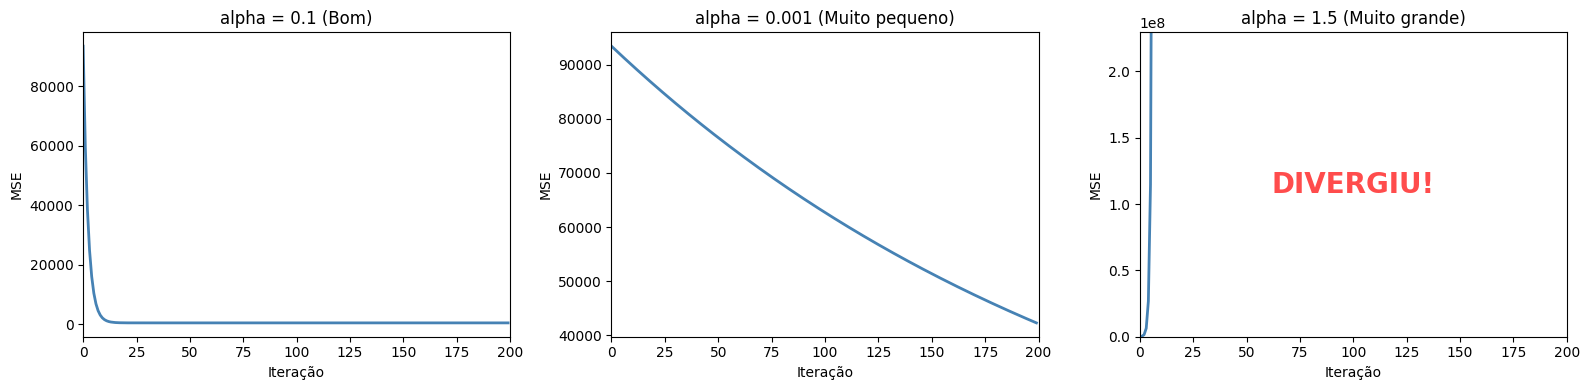

In [35]:
learning_rates = {
    'Bom (0.1)': 0.1,
    'Muito pequeno (0.001)': 0.001,
    'Muito grande (1.5)': 1.5,
}

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (label, lr) in zip(axes, learning_rates.items()):
    _, losses, _ = gradient_descent(X_gd, y, lr, 200)

    ax.plot(losses, color='steelblue', linewidth=2)
    ax.set_xlabel('Iteração')
    ax.set_ylabel('MSE')
    ax.set_title(f'alpha = {lr} ({label.split(" (")[0]})')
    ax.set_xlim(0, 200)

    # Limitar o eixo y para o caso divergente não explodir a escala
    if losses[-1] > 1e6:
        ax.set_ylim(0, losses[5] * 2 if len(losses) > 5 else losses[0] * 5)
        ax.text(0.5, 0.5, 'DIVERGIU!', transform=ax.transAxes,
                fontsize=20, color='red', ha='center', va='center',
                fontweight='bold', alpha=0.7)

plt.tight_layout()
plt.show()

In [36]:
# Comparação numérica
for label, lr in learning_rates.items():
    _, losses, _ = gradient_descent(X_gd, y, lr, 200)
    status = "DIVERGIU" if losses[-1] > losses[0] else f"MSE final = {losses[-1]:.2f}"
    print(f"  alpha = {lr:5.3f}: {status}")

  alpha = 0.100: MSE final = 454.63
  alpha = 0.001: MSE final = 42305.03
  alpha = 1.500: DIVERGIU


---
## 6. Visualização da Trajetória no Espaço de Parâmetros

Para visualizar a trajetória do gradient descent em 2D, vamos usar um modelo simples com **apenas uma feature** (`area_m2`), resultando em 2 parâmetros: $\theta_0$ (intercept) e $\theta_1$ (slope).

In [41]:
# Modelo univariado: preço ~ área
area_norm = (area - area.mean()) / area.std()
X_2d = np.column_stack([np.ones(n), area_norm])

# Solução OLS para referência
theta_ols_2d = np.linalg.inv(X_2d.T @ X_2d) @ X_2d.T @ y
print(f"OLS (2D): intercept = {theta_ols_2d[0]:.2f}, slope = {theta_ols_2d[1]:.2f}")

# Gradient descent
theta_gd_2d, losses_2d, path_2d = gradient_descent(
    X_2d, y, learning_rate=0.1, n_iterations=50
)
print(f"GD  (2D): intercept = {theta_gd_2d[0]:.2f}, slope = {theta_gd_2d[1]:.2f}")

OLS (2D): intercept = 290.45, slope = 86.25
GD  (2D): intercept = 290.45, slope = 86.25


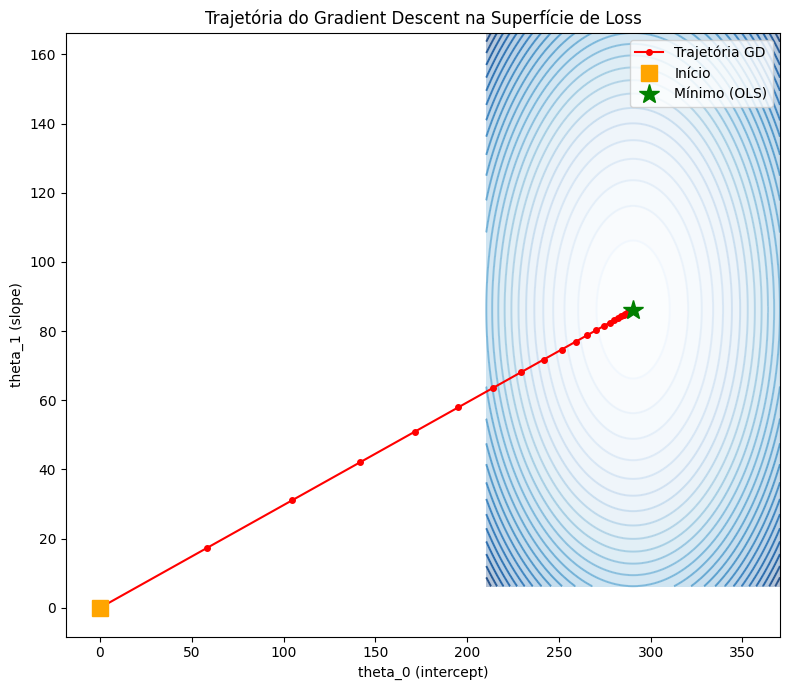

In [42]:
# Criar grade para a superfície de loss
t0_range = np.linspace(theta_ols_2d[0] - 80, theta_ols_2d[0] + 80, 200)
t1_range = np.linspace(theta_ols_2d[1] - 80, theta_ols_2d[1] + 80, 200)
T0, T1 = np.meshgrid(t0_range, t1_range)

# Calcular MSE para cada combinação (theta_0, theta_1)
MSE_surface = np.zeros_like(T0)
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        theta_ij = np.array([T0[i, j], T1[i, j]])
        residuals_ij = y - X_2d @ theta_ij
        MSE_surface[i, j] = np.mean(residuals_ij ** 2)

# Gráfico de contorno com trajetória do GD
fig, ax = plt.subplots(figsize=(8, 7))

# Contornos da superfície de loss
contour = ax.contour(T0, T1, MSE_surface, levels=30, cmap='Blues', alpha=0.7)
ax.contourf(T0, T1, MSE_surface, levels=30, cmap='Blues', alpha=0.3)

# Trajetória do GD
ax.plot(path_2d[:, 0], path_2d[:, 1], 'o-', color='red',
        markersize=4, linewidth=1.5, label='Trajetória GD', zorder=5)

# Ponto inicial e final
ax.plot(path_2d[0, 0], path_2d[0, 1], 's', color='orange',
        markersize=12, label='Início', zorder=6)
ax.plot(theta_ols_2d[0], theta_ols_2d[1], '*', color='green',
        markersize=15, label='Mínimo (OLS)', zorder=6)

ax.set_xlabel('theta_0 (intercept)')
ax.set_ylabel('theta_1 (slope)')
ax.set_title('Trajetória do Gradient Descent na Superfície de Loss')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

O gradient descent começa no ponto inicial (quadrado laranja) e segue iterativamente na direção de maior descida até chegar próximo ao mínimo (estrela verde) — que é exatamente a solução OLS.

---
## 7. Comparação: Gradient Descent vs OLS

Para comparar os parâmetros do GD (que foram estimados no espaço normalizado) com os do OLS (espaço original), precisamos **converter os parâmetros de volta** ao espaço original.

In [43]:
# Converter parâmetros do espaço normalizado para o original
# Se x_norm = (x - mu) / sigma, então:
# theta_orig_j = theta_norm_j / sigma_j
# theta_orig_0 = theta_norm_0 - sum(theta_norm_j * mu_j / sigma_j)

theta_gd_orig = np.zeros(4)
theta_gd_orig[1:] = theta_gd[1:] / X_std  # coeficientes das features
theta_gd_orig[0] = theta_gd[0] - np.sum(theta_gd[1:] * X_mean / X_std)  # intercept

In [44]:
# Tabela comparativa
true_params = [TRUE_INTERCEPT, TRUE_BETA_AREA, TRUE_BETA_ROOMS, TRUE_BETA_AGE]
param_names = ['const', 'area_m2', 'rooms', 'age_years']

comparison = pd.DataFrame({
    'Verdadeiro': true_params,
    'OLS': theta_ols,
    'Gradient Descent': theta_gd_orig
}, index=param_names)

comparison['Diferença (GD - OLS)'] = comparison['Gradient Descent'] - comparison['OLS']

comparison

,Verdadeiro,OLS,Gradient Descent,Diferença (GD - OLS)
const,50.0,42.679561,42.679561,1.108447e-12
area_m2,2.5,2.645905,2.645905,-1.554312e-14
rooms,15.0,14.065701,14.065701,-2.309264e-14
age_years,-1.5,-1.591179,-1.591179,9.992007e-15


In [45]:
max_diff = np.max(np.abs(theta_gd_orig - theta_ols))
print(f"Diferença máxima entre GD e OLS: {max_diff:.6f}")

if max_diff < 0.1:
    print("Os resultados são praticamente idênticos!")
else:
    print("Tente aumentar o número de iterações ou ajustar a learning rate.")

Diferença máxima entre GD e OLS: 0.000000
Os resultados são praticamente idênticos!


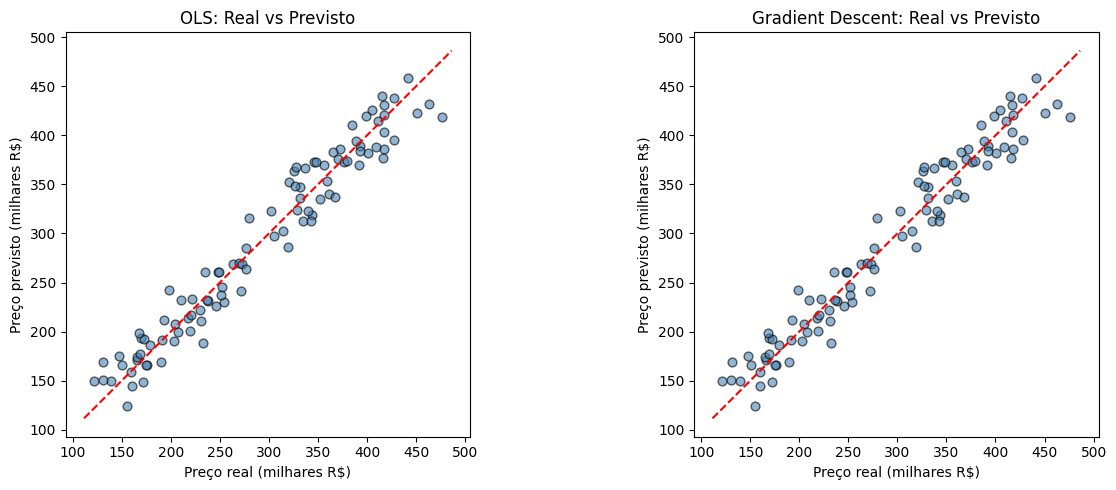

In [46]:
# Comparação visual: previsões GD vs OLS
y_pred_ols = X_ols @ theta_ols
y_pred_gd = X_ols @ theta_gd_orig

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_pred, title in zip(axes,
                              [y_pred_ols, y_pred_gd],
                              ['OLS', 'Gradient Descent']):
    ax.scatter(y, y_pred, alpha=0.6, color='steelblue', edgecolors='black', s=40)
    lims = [y.min() - 10, y.max() + 10]
    ax.plot(lims, lims, 'r--', linewidth=1.5)
    ax.set_xlabel('Preço real (milhares R$)')
    ax.set_ylabel('Preço previsto (milhares R$)')
    ax.set_title(f'{title}: Real vs Previsto')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---
## 8. Resumo

| | OLS (analítico) | Gradient Descent (iterativo) |
|---|---|---|
| **Como funciona** | Resolve as equações normais diretamente | Atualiza $\theta$ iterativamente seguindo o negativo do gradiente |
| **Resultado** | Solução exata em uma única operação | Aproxima a solução, convergindo com número suficiente de iterações |
| **Quando usar** | Quando existe solução analítica (regressão linear + loss L2) | Quando **não** existe solução analítica (redes neurais, regressão logística, etc.) |
| **Custo computacional** | Inverter $\mathbf{X}^\top\mathbf{X}$ — caro para muitas features ($O(p^3)$) | Cada iteração é $O(np)$ — escala melhor para datasets grandes |
| **Hiperparâmetros** | Nenhum | Learning rate $\alpha$, número de iterações |